In [1]:
import cv2, glob, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
from loguru import logger
from PIL import Image
log = logger.debug
cv = cv2

In [17]:
images = sorted(glob.glob("/Volumes/BroadKey0313/DCIM/Calibration2/*.JPG"))[6:]

In [18]:
# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

grid = [7, 7]

# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((grid[0] * grid[1],3), np.float32)
objp[:,:2] = np.mgrid[0:grid[0], 0:grid[1]].T.reshape(-1,2)
 
# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.


In [26]:
def check_orthogonality(corners):
    if corners.shape[0] != 49:
        return False
    corners = corners.reshape((7, 7, 2))
    V = (corners[:, 1:] - corners[:, :-1]).reshape(-1, 2)
    V /= np.linalg.norm(V, axis=-1)[..., np.newaxis]
    V = np.abs(V @ V.T).min()
    res = V > 0.99
    if not res:
        logger.warning(f"Found sim of {V}")
    return res

def find_corners(image, downsample=3):
    img = cv.imread(image)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray_small = gray.copy()
    for _ in range(downsample):
        gray_small = cv2.pyrDown(gray_small)

    ret, corners = cv.findChessboardCorners(gray_small, (7, 7), None)
    
    if ret == True:
        remap = 2 ** downsample

        corners2 = cv.cornerSubPix(gray_small,corners, (11,11), (-1,-1), criteria)
    
        corners3 = cv.cornerSubPix(gray, corners2 * (2 ** downsample), (11,11), (-1,-1), criteria)
        if check_orthogonality(corners3) and check_orthogonality(corners3[..., ::-1]):
            cv.drawChessboardCorners(img, (8, 8), corners3, ret)
            cv.imshow('img', img)
            cv.waitKey(1)
            return objp, corners3
    


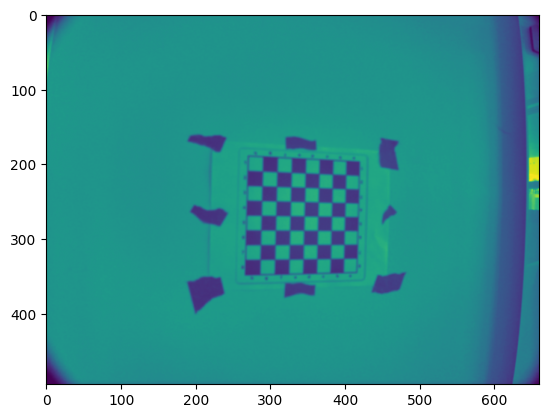

In [27]:
img = cv.imread(images[-3])
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_small = gray.copy()
downsample = 3
for _ in range(downsample):
    gray_small = cv2.pyrDown(gray_small)
plt.imshow(gray_small)

In [28]:
for fname in tqdm(images):
    res = find_corners(fname)
    if res is None:
        logger.warning(f"Failed to find corners for {fname}")
        continue
    objpoints.append(res[0])
    imgpoints.append(res[1])
cv.destroyAllWindows()

  0%|                                                    | 0/53 [00:00<?, ?it/s]2026-05-07 15:43:08.804 | WARNING  | __main__:check_orthogonality:10 - Found sim of 0.2365627884864807
2026-05-07 15:43:08.808 | WARNING  | __main__:<module>:4 - Failed to find corners for /Volumes/BroadKey0313/DCIM/Calibration2/DJI_20260507153824_0007_V.JPG
  2%|▊                                           | 1/53 [00:00<00:06,  8.12it/s]2026-05-07 15:43:08.910 | WARNING  | __main__:check_orthogonality:10 - Found sim of 0.9424763917922974
2026-05-07 15:43:08.913 | WARNING  | __main__:<module>:4 - Failed to find corners for /Volumes/BroadKey0313/DCIM/Calibration2/DJI_20260507153825_0008_V.JPG
  4%|█▋                                          | 2/53 [00:00<00:05,  8.87it/s]2026-05-07 15:43:09.006 | WARNING  | __main__:check_orthogonality:10 - Found sim of 0.8595069646835327
2026-05-07 15:43:09.008 | WARNING  | __main__:<module>:4 - Failed to find corners for /Volumes/BroadKey0313/DCIM/Calibration2/DJI_202605071

In [29]:
ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)


In [30]:
ret

3.2803930923483327

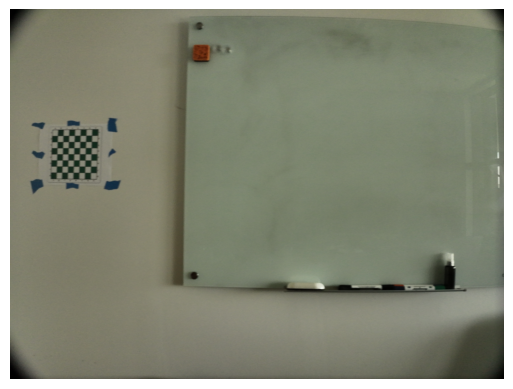

In [31]:
img = cv.imread(images[0])
h,  w = img.shape[:2]
newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 0, (w,h))
plt.imshow(img[..., ::-1])
_ = plt.axis('off')

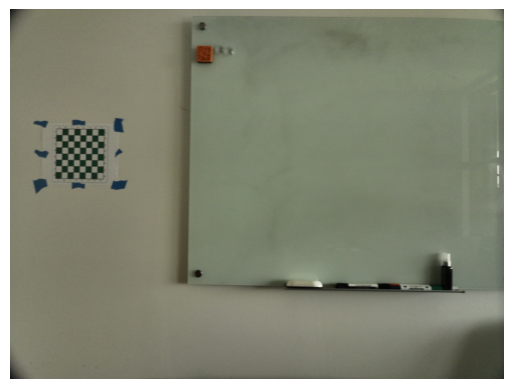

In [32]:
# undistort
dst = cv.undistort(img, mtx, dist, None, newcameramtx)

# crop the image
x, y, w, h = roi
dst = dst[y:y+h, x:x+w]
plt.imshow(dst[..., ::-1])
_ = plt.axis('off')

In [33]:
dst.shape

(3955, 5279, 3)

In [34]:
img.shape

(3956, 5280, 3)

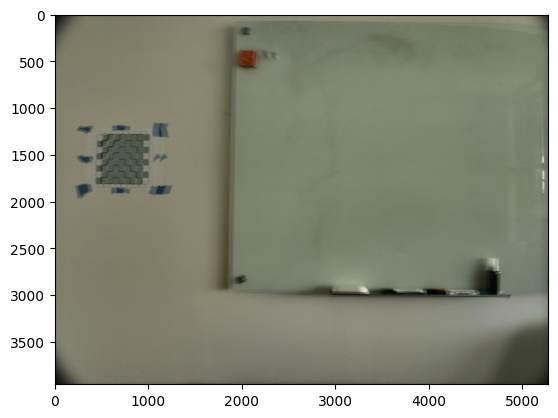

In [35]:
plt.imshow(
    ((dst.astype(np.float32) + img[1:, 1:].astype(np.float32)) / 255 / 2)[..., ::-1]
)

In [37]:
np.save("calibration.npy", {"mtx": mtx, "dist": dist, "newcameramtx": newcameramtx})

In [39]:
np.load("calibration.npy", allow_pickle=True)

array({'mtx': array([[4.15931925e+03, 0.00000000e+00, 2.78741201e+03],
       [0.00000000e+00, 4.15868103e+03, 1.95245366e+03],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]]), 'dist': array([[-0.06616684, -0.21278618, -0.00073076, -0.00290966,  0.20773544]]), 'newcameramtx': array([[3.93625403e+03, 0.00000000e+00, 2.78975118e+03],
       [0.00000000e+00, 4.05472708e+03, 1.94840381e+03],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}, dtype=object)